In [1]:
# Импорт всех необходимых библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# Поиск пути фйла с табличными данными из Kaggle
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
# Создание датафрейма и просмотр верхних 5-ти значений
train_data = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Первичный анализ датасета
train_data.info()
train_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Поиск и подсчет количества пропусков
missing = train_data.isnull().sum()
missing_pct = (missing / len(train_data) * 100).round(1)
missing_df = pd.DataFrame({"Количество": missing, "Процент (%)": missing_pct})
print(missing_df[missing_df["Количество"] > 0])

          Количество  Процент (%)
Age              177         19.9
Cabin            687         77.1
Embarked           2          0.2


In [5]:
# Заполняем пропуски (для возраста - медиана, для порта посадки - мода)
train_data["Age"] = train_data["Age"].fillna(train_data["Age"].median())
train_data["Embarked"] = train_data["Embarked"].fillna(train_data["Embarked"].mode()[0])

In [6]:
# Константы цветов для графиков
GREEN = "#1D9E75"
RED = "#E24B4A"
BLUE = "#378ADD"
AMBER = "#EF9F27"
PURPLE = "#7F77DD"

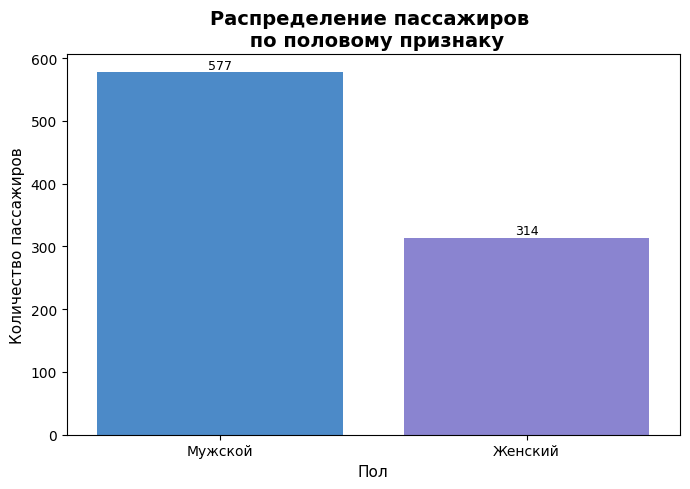

In [7]:
# Настройка холста и сетки
fig, axes = plt.subplots(1,1, figsize=(7,5))

# Столбчатая диаграмма распределения пассажиров по половому признаку
sns.countplot(
    data=train_data,
    x="Sex",
    hue="Sex",
    palette=[BLUE, PURPLE],
    legend=False,
    ax=axes
)

# Настройка заголовка, подписей осей и категорий
axes.set_title("Распределение пассажиров \n по половому признаку", 
             fontsize=14, fontweight="bold")
axes.set_xlabel("Пол", fontsize=11)
axes.set_ylabel("Количество пассажиров", fontsize=11)
axes.set_xticks([0, 1])
axes.set_xticklabels(["Мужской", "Женский"])

# Подписи значений над столбиками
for p in axes.patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes.annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 5), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиком в формате .svg
fig.savefig("plot1.svg")

In [8]:
def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers

fare_outliers = find_outliers_iqr(train_data["Fare"])
age_outliers = find_outliers_iqr(train_data["Age"].dropna())

print(f"Fare выбросы:\n{fare_outliers}")
print(f"Age выбросы:\n{age_outliers}")

Fare выбросы:
1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64
Age выбросы:
7       2.00
11     58.00
15     55.00
16      2.00
33     66.00
       ...  
827     1.00
829    62.00
831     0.83
851    74.00
879    56.00
Name: Age, Length: 66, dtype: float64


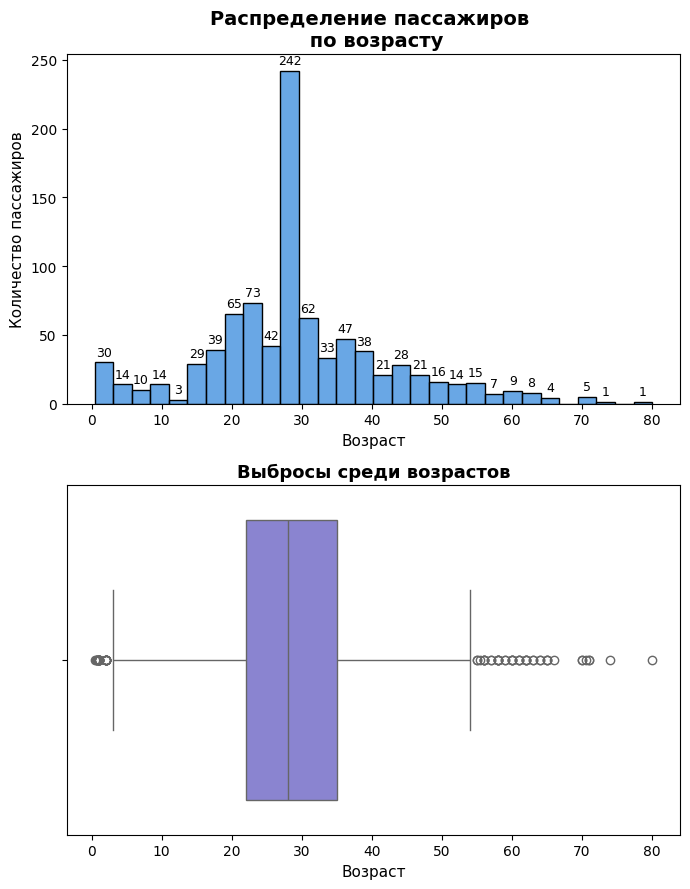

In [9]:
# Настройка холста и сетки
fig, axes = plt.subplots(2,1, figsize=(7,9))

# Гистограмма распределения пассажиров по возрасту
sns.histplot(
    data=train_data,
    x="Age",
    color=BLUE,
    ax = axes[0]
)

# Настройка заголовка и подписей осей
axes[0].set_title("Распределение пассажиров \n по возрасту", 
             fontsize=14, fontweight="bold")
axes[0].set_xlabel("Возраст", fontsize=11)
axes[0].set_ylabel("Количество пассажиров", fontsize=11)

# Подписи значений над столбиками
for p in axes[0].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes[0].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 5), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )
# "Ящик с усами" для обнаружения выбросов среди возрастов
sns.boxplot(
    data=train_data,
    x="Age",
    color=PURPLE,
    ax=axes[1]
)

# Заголовок и подписи к осям
axes[1].set_title("Выбросы среди возрастов", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Возраст", fontsize=11)

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиками в формате .svg
fig.savefig("plot2-3.svg")

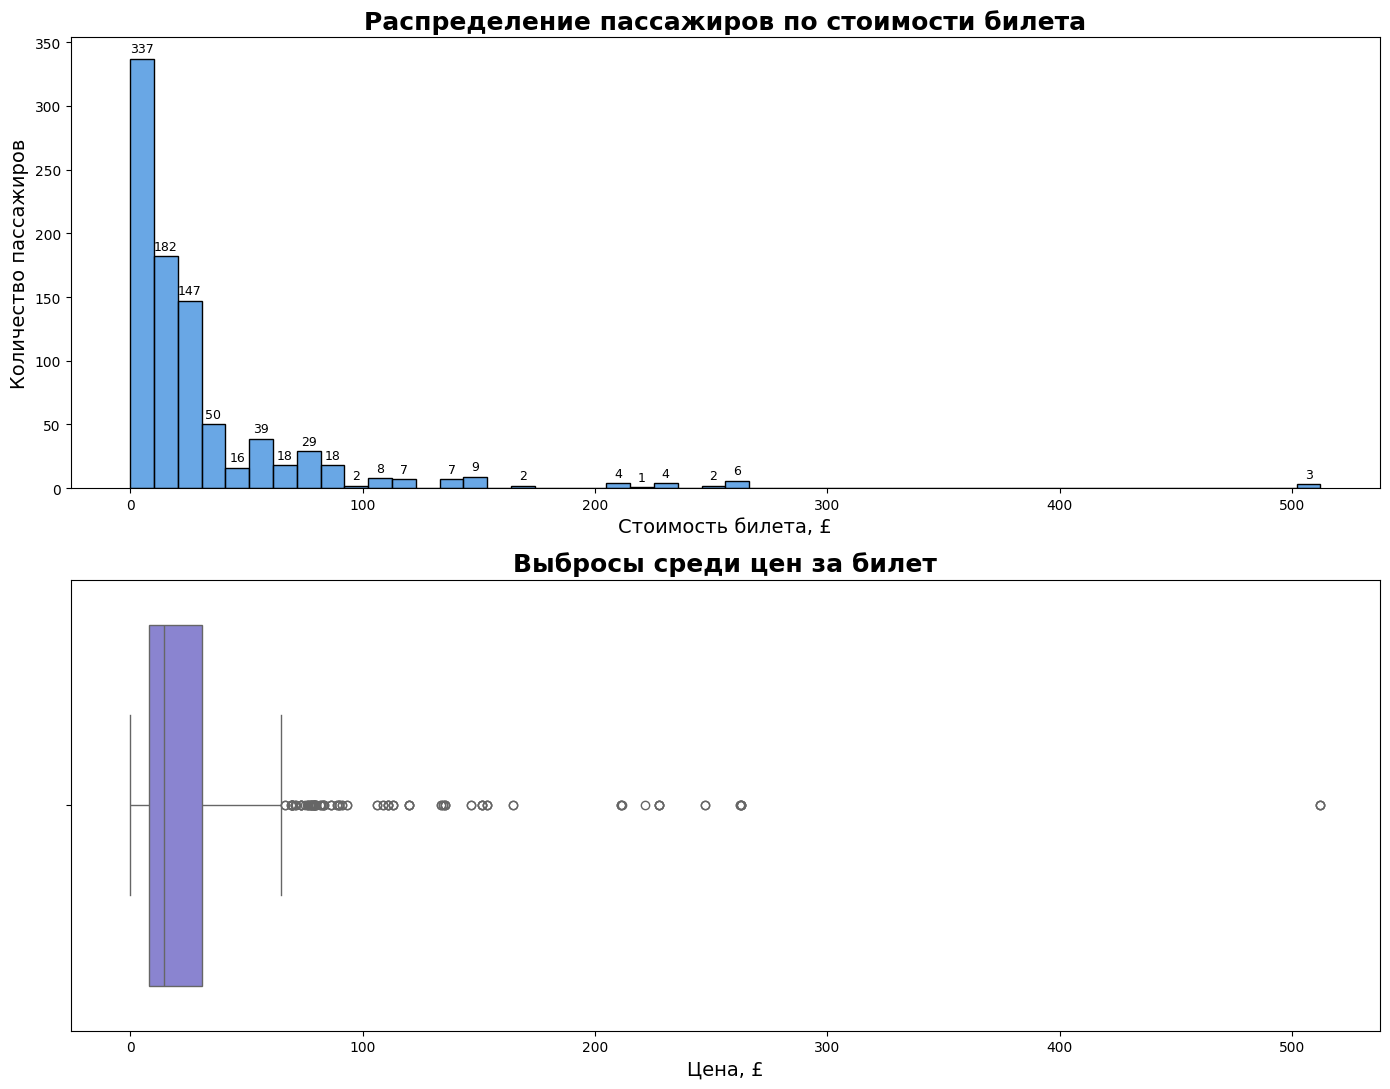

In [24]:
# Настройка холста и сетки
fig, axes = plt.subplots(2,1, figsize=(14,11))

# Гистограмма распределения пассажиров по стоимости билета
sns.histplot(
    data=train_data,
    x="Fare",
    bins=50,
    color=BLUE,
    ax=axes[0]
)

# Настройка заголовка и подписей осей
axes[0].set_title("Распределение пассажиров по стоимости билета", 
                  fontsize=18, fontweight="bold")
axes[0].set_xlabel("Стоимость билета, £", fontsize=14)
axes[0].set_ylabel("Количество пассажиров", fontsize=14)

# Подписи значений над столбиками
for p in axes[0].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes[0].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 5), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# "Ящик с усами" для обнаружения выбросов среди цен за билет
sns.boxplot(
    data=train_data,
    x="Fare",
    color=PURPLE,
    ax=axes[1]
)

# Заголовок и подписи к осям
axes[1].set_title("Выбросы среди цен за билет", fontsize=18, fontweight="bold")
axes[1].set_xlabel("Цена, £", fontsize=14)

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиками в формате .svg
fig.savefig("plot4-5.svg")

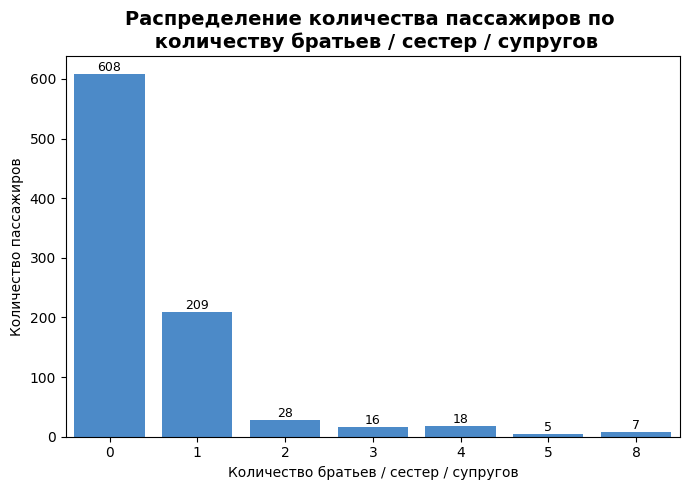

In [11]:
# Настройка холста и сетки
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

# Столбчатая диаграмма распределения количества пассажиров по количеству 
# братьев / сестер / супругов
sns.countplot(
    data=train_data,
    x="SibSp",
    color=BLUE,  # один цвет или палитра
    ax=axes
)

# Настройка заголовка и подписей осей
axes.set_title("Распределение количества пассажиров по \n количеству братьев / сестер / супругов", 
             fontsize=14, fontweight="bold")
axes.set_xlabel("Количество братьев / сестер / супругов", fontsize=10)
axes.set_ylabel("Количество пассажиров", fontsize=10)

# Подписи значений над столбиками
for p in axes.patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes.annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 5), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиками в формате .svg
fig.savefig("plot6.svg")

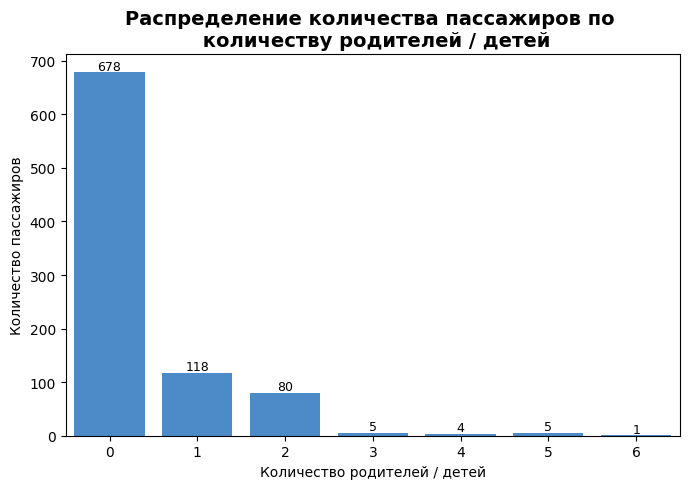

In [12]:
# Настройка холста и сетки 
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

# Столбчатая диаграмма распределения количества пассажиров по количеству 
# родителей / детей
sns.countplot(
    data=train_data,
    x="Parch",
    color=BLUE,
    ax=axes
)

# Настройка заголовка и подписей осей
axes.set_title("Распределение количества пассажиров по \n количеству родителей / детей", 
             fontsize=14, fontweight="bold")
axes.set_xlabel("Количество родителей / детей", fontsize=10)
axes.set_ylabel("Количество пассажиров", fontsize=10)

# Подписи значений над столбиками
for p in axes.patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes.annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 5), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиками в формате .svg
fig.savefig("plot7.svg")

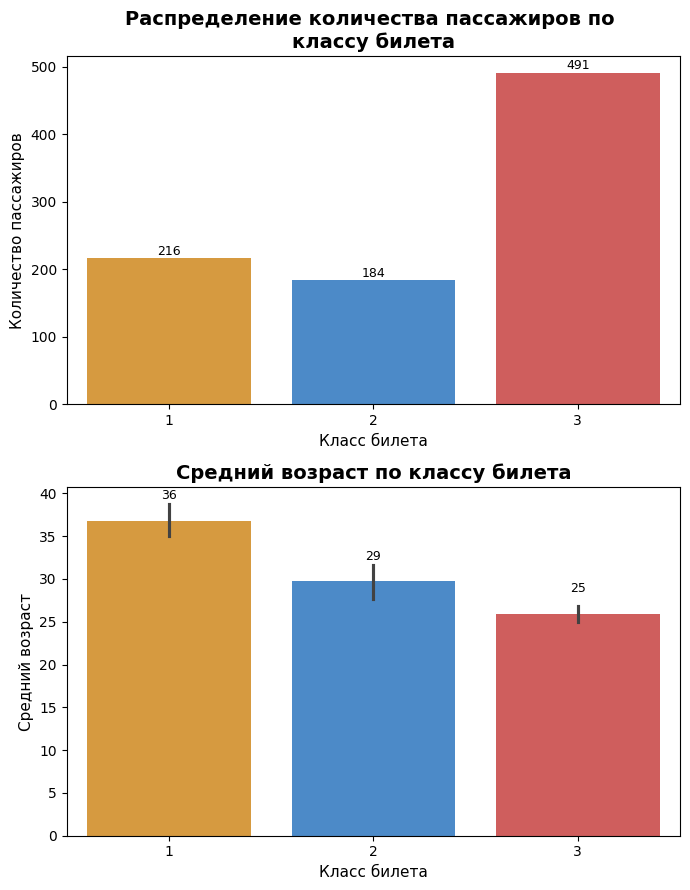

In [25]:
# Настройка холста и сетки 
fig, axes = plt.subplots(2, 1, figsize=(7, 9))

# Столбчатая диаграмма распределения количества пассажиров по классу билета
sns.countplot(
    data=train_data,
    x="Pclass",
    hue="Pclass",
    palette=[AMBER, BLUE, RED],
    legend=False,
    ax=axes[0]
)

# Настройка заголовка и подписей осей
axes[0].set_title("Распределение количества пассажиров по \nклассу билета", 
                  fontsize=14, fontweight="bold")
axes[0].set_xlabel("Класс билета", fontsize=11)
axes[0].set_ylabel("Количество пассажиров", fontsize=11)

# Подписи значений над столбиками
for p in axes[0].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes[0].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 5), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Столбчатая диаграмма среднего возраста в каждом классе
sns.barplot(
    data=train_data,
    x="Pclass",        
    y="Age",        
    hue="Pclass",
    palette=[AMBER, BLUE, RED],
    legend=False,
    ax=axes[1]
)

# Настройка заголовка и подписей осей
axes[1].set_title("Средний возраст по классу билета", 
             fontsize=14, fontweight="bold")
axes[1].set_xlabel("Класс билета", fontsize=11)
axes[1].set_ylabel("Средний возраст", fontsize=11)

# Подписи значений над столбиками
for p in axes[1].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes[1].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 2.5), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиками в формате .svg
fig.savefig("plot8-9.svg")

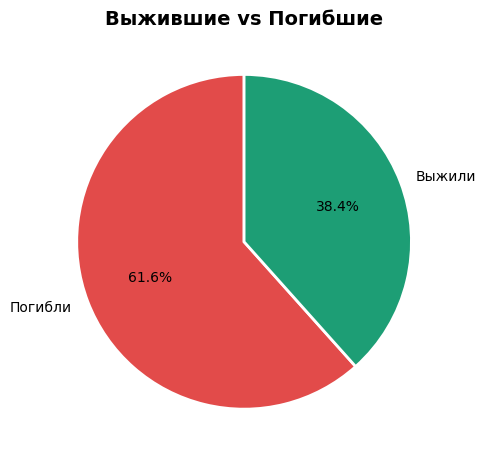

In [14]:
# Создание подложки для графика (Доли выживших и погибших)
fig = plt.figure(figsize=(5, 5))

# Круговая диаграмма выживших и погибших
ax = fig.add_subplot()
counts = train_data["Survived"].value_counts()
ax.pie(
    counts,
    labels=["Погибли", "Выжили"],
    colors=[RED, GREEN],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)

# Настройка заголовка графика
ax.set_title("Выжившие vs Погибшие", fontsize=14, fontweight="bold")

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиком в формате .svg
fig.savefig("plot10.svg")

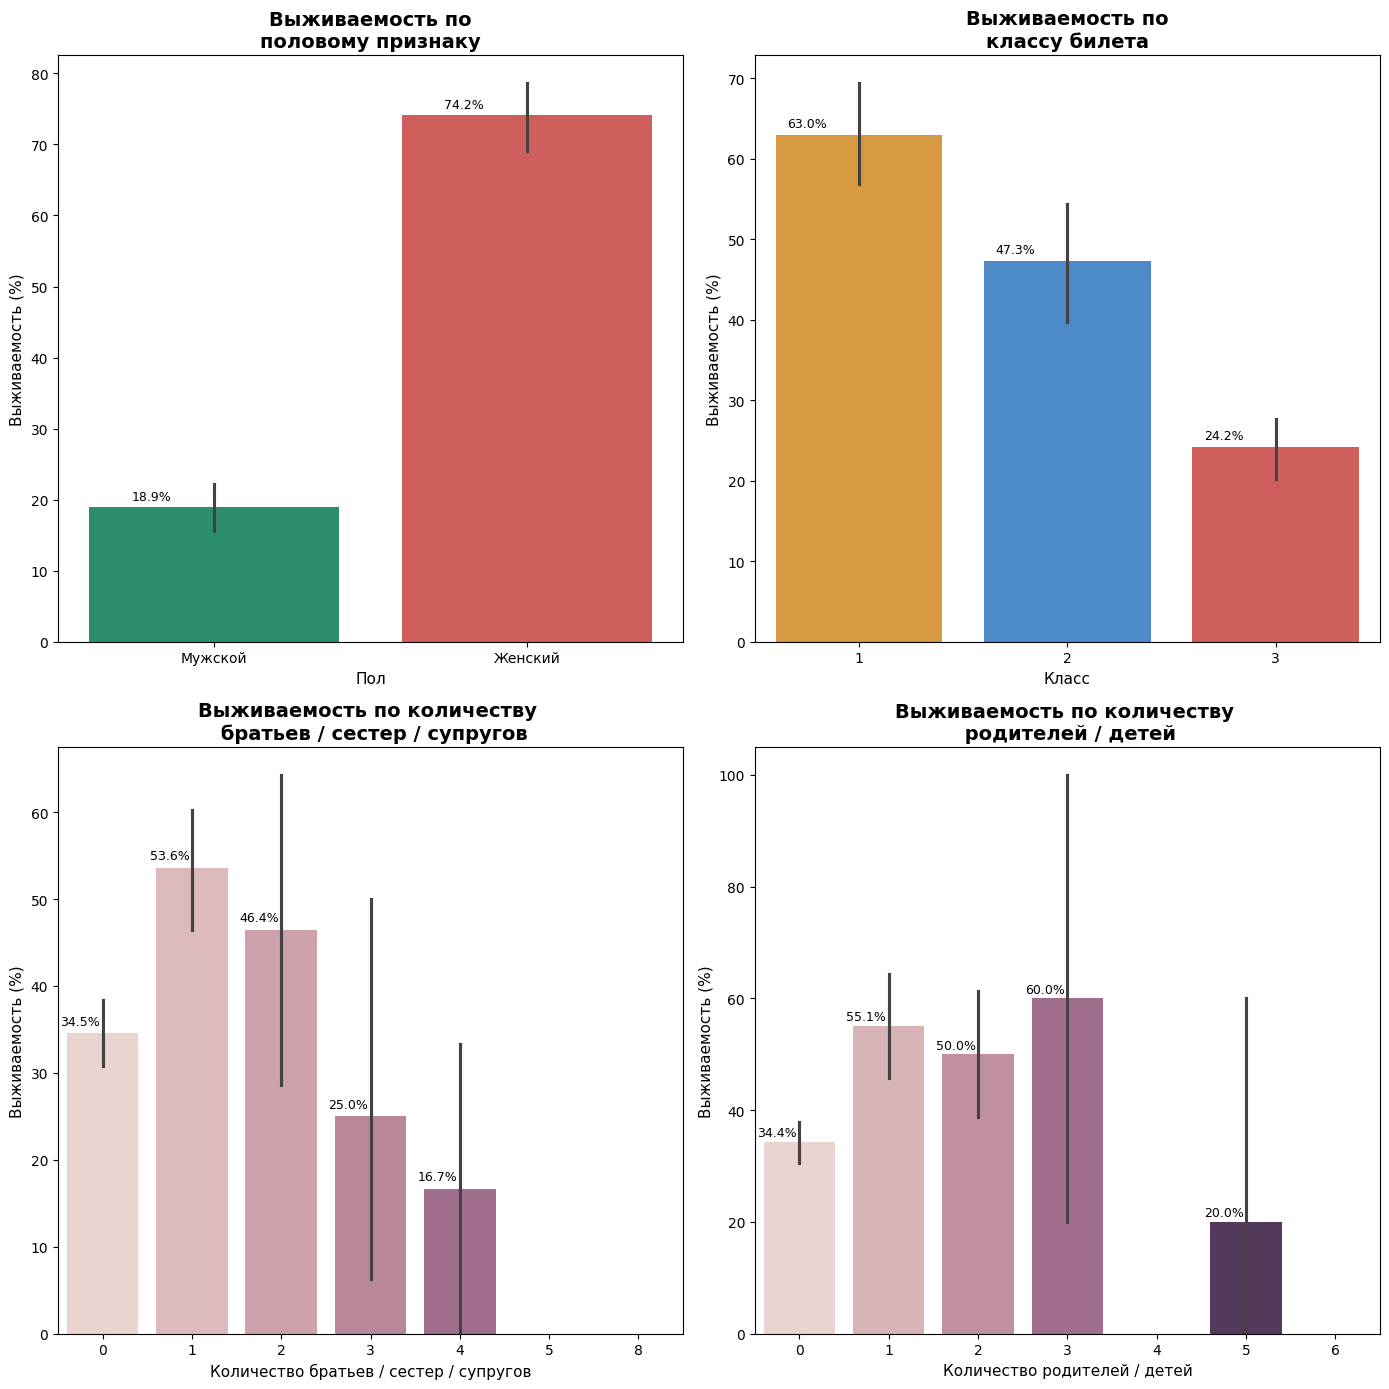

In [15]:
# Настройка холста и сетки 
fig, axes = plt.subplot_mosaic(
    [
        ["sex", "class"],
        ["SibSp", "Parch"]
    ],
    figsize=(14, 14)
)

# Столбчатая диаграмма выживаемости по половому признаку
sns.barplot(
    data=train_data,
    x="Sex",
    y="Survived",
    estimator=lambda x: x.mean() * 100,
    hue="Sex",
    palette=[GREEN, RED],
    ax=axes["sex"]
)

# Настройка заголовка, подписей осей и столбцов
axes["sex"].set_title("Выживаемость по\nполовому признаку", 
                      fontsize=14, fontweight="bold")
axes["sex"].set_xlabel("Пол", fontsize=11)
axes["sex"].set_ylabel("Выживаемость (%)", fontsize=11)
axes["sex"].set_xticks([0, 1])
axes["sex"].set_xticklabels(["Мужской", "Женский"])

# Подписи значений над столбиками
for p in axes["sex"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["sex"].annotate(
            f"{height:.1f}%", # процент с 1 знаком после разделителя
            (p.get_x() + p.get_width()/2 - 0.2, height + 1), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Столбчатая диаграмма выживаемости по классу билета
sns.barplot(
    data=train_data,
    x="Pclass",
    y="Survived",
    estimator=lambda x: x.mean() * 100,
    hue="Pclass",
    palette=[AMBER, BLUE, RED],
    legend=False,
    ax=axes["class"]
)

# Настройка заголовка, подписей осей и столбцов
axes["class"].set_title("Выживаемость по\nклассу билета", 
                        fontsize=14, fontweight="bold")
axes["class"].set_xlabel("Класс", fontsize=11)
axes["class"].set_ylabel("Выживаемость (%)", fontsize=11)
axes["class"].set_xticks([0, 1, 2])
axes["class"].set_xticklabels(["1", "2", "3"])

# Подписи значений над столбиками
for p in axes["class"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["class"].annotate(
            f"{height:.1f}%", # процент с 1 знаком после разделителя
            (p.get_x() + p.get_width()/2- 0.25, height + 1), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Столбчатая диаграмма выживаемости по количеству братьев / сестер / супругов
sns.barplot(
    data=train_data,
    x="SibSp",
    y="Survived",
    estimator=lambda x: x.mean() * 100,
    hue="SibSp",
    legend=False,
    ax=axes["SibSp"]
)

# Настройка заголовка, подписей осей и столбцов
axes["SibSp"].set_title("Выживаемость по количеству \n братьев / сестер / супругов", 
                        fontsize=14, fontweight="bold")
axes["SibSp"].set_xlabel("Количество братьев / сестер / супругов", fontsize=11)
axes["SibSp"].set_ylabel("Выживаемость (%)", fontsize=11)

# Подписи значений над столбиками
for p in axes["SibSp"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["SibSp"].annotate(
            f"{height:.1f}%", # процент с 1 знаком после разделителя
            (p.get_x() + p.get_width()/2- 0.25, height + 1), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Столбчатая диаграмма выживаемости по количеству родителей / детей
sns.barplot(
    data=train_data,
    x="Parch",
    y="Survived",
    estimator=lambda x: x.mean() * 100,
    hue="Parch",
    legend=False,
    ax=axes["Parch"]
)

# Настройка заголовка и подписей осей
axes["Parch"].set_title("Выживаемость по количеству \n родителей / детей", 
                        fontsize=14, fontweight="bold")
axes["Parch"].set_xlabel("Количество родителей / детей", fontsize=11)
axes["Parch"].set_ylabel("Выживаемость (%)", fontsize=11)

# Подписи значений над столбиками
for p in axes["Parch"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["Parch"].annotate(
            f"{height:.1f}%", # процент с 1 знаком после разделителя
            (p.get_x() + p.get_width()/2- 0.25, height + 1), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиком в формате .svg
fig.savefig("plot11-14.svg")


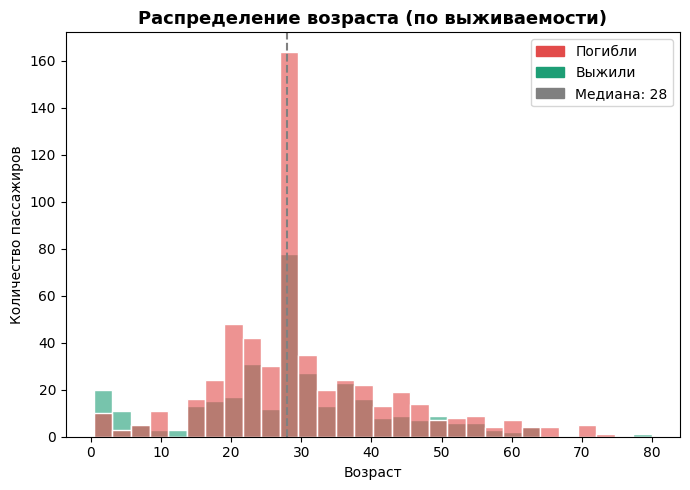

In [16]:
# Настройка холста и сетки 
fig, ax = plt.subplots(figsize=(7, 5))

# Гистограмма распределения возраста по выживаемости
sns.histplot(
    data=train_data,
    x="Age",
    hue="Survived",
    bins=30,
    palette=[RED, GREEN],
    alpha=0.6,
    edgecolor="white",
    ax=ax
)

# Поиск медианы
median_age = train_data["Age"].median()

# Настройка медианы на графике
ax.axvline(
    median_age,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Медиана: {median_age:.0f}"
)

# Настройка заголовка и подписей осей
ax.set_title("Распределение возраста (по выживаемости)", fontsize=13, fontweight="bold")
ax.set_xlabel("Возраст")
ax.set_ylabel("Количество пассажиров")

# Настройка кастомной легенды
patch_survived = mpatches.Patch(color=GREEN, label="Выжили")
patch_died = mpatches.Patch(color=RED, label="Погибли")
line_median = mpatches.Patch(color="gray", label=f"Медиана: {median_age:.0f}", hatch='//')

# Установка легенды
ax.legend(handles=[patch_died, patch_survived, line_median])

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиком в формате .svg
fig.savefig("plot15.svg")

In [29]:
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1

train_data["IsAlone"] = (train_data["FamilySize"] == 1).astype(int)

bins = [0, 1, 3, 12, 17, 34, 60, 120]
labels = ["0-1 (Младенцы)", "1-3 (Малыши)", "4-12 (Дети)", "13-17 (Подростки)", 
          "18-34 (Молодежь)", "35-60 (Взрослые)", "60+ (Возрастные)"]

train_data["AgeGroup"] = pd.cut(train_data["Age"], bins=bins, labels=labels)
train_data["Title"] = train_data["Name"].str.extract(r',\s*([^\.]+)\.')

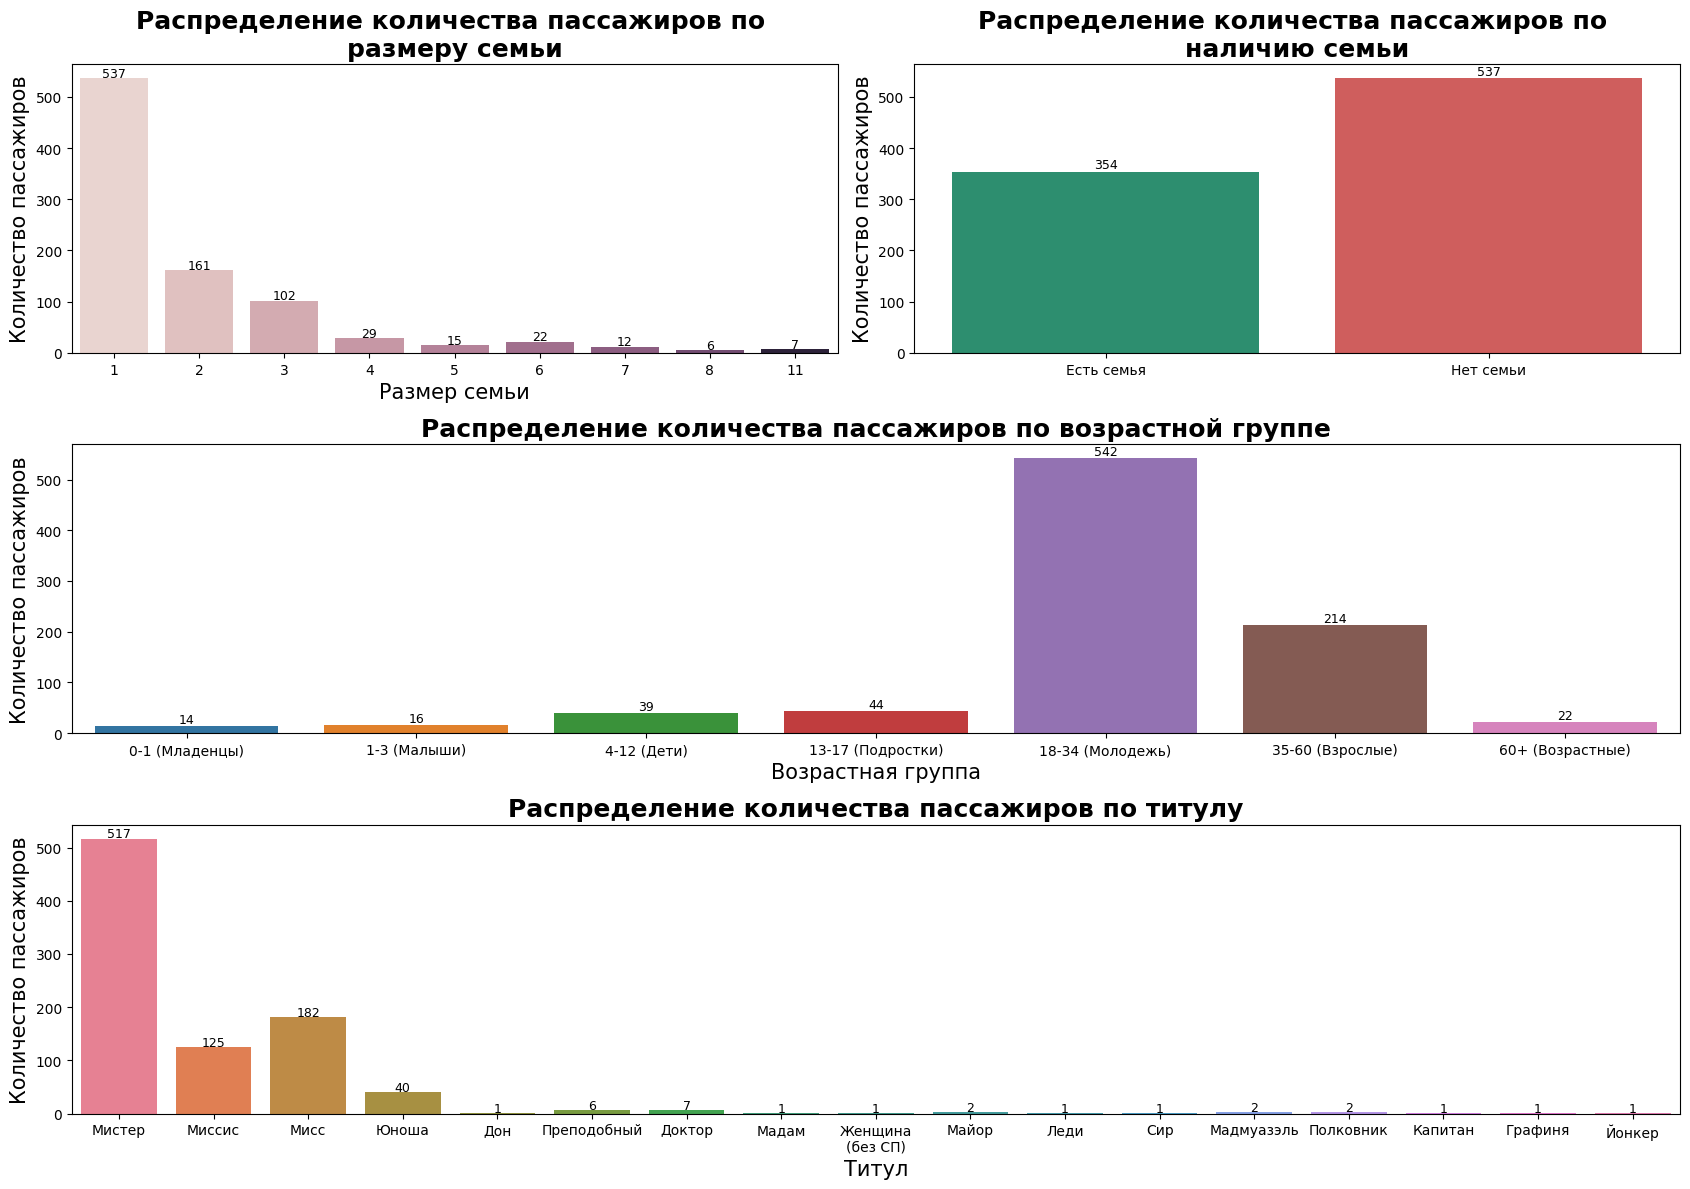

In [46]:
# Настройка холста и сетки 
fig, axes = plt.subplot_mosaic(
    [
        ["FamilySize", "IsAlone"],
        ["AgeGroup", "AgeGroup"],
        ["Title", "Title"]
    ],
    figsize=(17, 12)
)

# Столбчатая диаграмма распределения количества пассажиров по размеру семьи
sns.countplot(
    data=train_data,
    x="FamilySize",        
    hue="FamilySize",
    legend=False,
    ax=axes["FamilySize"]
)

# Настройка заголовка и подписей осей
axes["FamilySize"].set_title("Распределение количества пассажиров по \nразмеру семьи", 
             fontsize=18, fontweight="bold")
axes["FamilySize"].set_xlabel("Размер семьи", fontsize=15)
axes["FamilySize"].set_ylabel("Количество пассажиров", fontsize=15)

# Подписи значений над столбиками
for p in axes["FamilySize"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["FamilySize"].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 2.5), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Столбчатая диаграмма распределения количества одиноких пассажиров
sns.countplot(
    data=train_data,
    x="IsAlone",        
    hue="IsAlone",
    palette=[GREEN, RED],
    legend=False,
    ax=axes["IsAlone"]
)

# Настройка заголовка, подписей осей и столбцов
axes["IsAlone"].set_title("Распределение количества пассажиров по \nналичию семьи", 
             fontsize=18, fontweight="bold")
axes["IsAlone"].set_xlabel("", fontsize=15)
axes["IsAlone"].set_ylabel("Количество пассажиров", fontsize=15)
axes["IsAlone"].set_xticks([0, 1])
axes["IsAlone"].set_xticklabels(["Есть семья", "Нет семьи"])

# Подписи значений над столбиками
for p in axes["IsAlone"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["IsAlone"].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 6.1), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Столбчатая диаграмма распределения количества пассажиров по возрастным группам
sns.countplot(
    data=train_data,
    x="AgeGroup",        
    hue="AgeGroup",
    legend=False,
    ax=axes["AgeGroup"]
)

# Настройка заголовка, подписей осей и столбцов
axes["AgeGroup"].set_title("Распределение количества пассажиров по возрастной группе", 
             fontsize=18, fontweight="bold")
axes["AgeGroup"].set_xlabel("Возрастная группа", fontsize=15)
axes["AgeGroup"].set_ylabel("Количество пассажиров", fontsize=15)
axes["AgeGroup"].set_xticks([0, 1, 2, 3, 4, 5, 6])
axes["AgeGroup"].set_xticklabels(["0-1 (Младенцы)", "1-3 (Малыши)", 
                                  "4-12 (Дети)", "13-17 (Подростки)", 
                                  "18-34 (Молодежь)", "35-60 (Взрослые)", 
                                  "60+ (Возрастные)"])

# Подписи значений над столбиками
for p in axes["AgeGroup"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["AgeGroup"].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 6.1), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Столбчатая диаграмма распределения выживаемости по титулу
sns.countplot(
    data=train_data,
    x="Title",        
    hue="Title",
    legend=False,
    ax=axes["Title"]
)

# Настройка заголовка, подписей осей и столбцов
axes["Title"].set_title("Распределение количества пассажиров по титулу", 
             fontsize=18, fontweight="bold")
axes["Title"].set_xlabel("Титул", fontsize=15)
axes["Title"].set_ylabel("Количество пассажиров", fontsize=15)
axes["Title"].set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16])
axes["Title"].set_xticklabels(["Мистер", "Миссис", "Мисс", "Юноша", "Дон", "Преподобный", 
                               "Доктор", "Мадам", "Женщина\n(без СП)", "Майор", "Леди",
                               "Сир", "Мадмуазэль", "Полковник", "Капитан", "Графиня", 
                               "Йонкер"])

# Подписи значений над столбиками
for p in axes["Title"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["Title"].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 2), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиками в формате .svg
fig.savefig("plot16-19.svg")

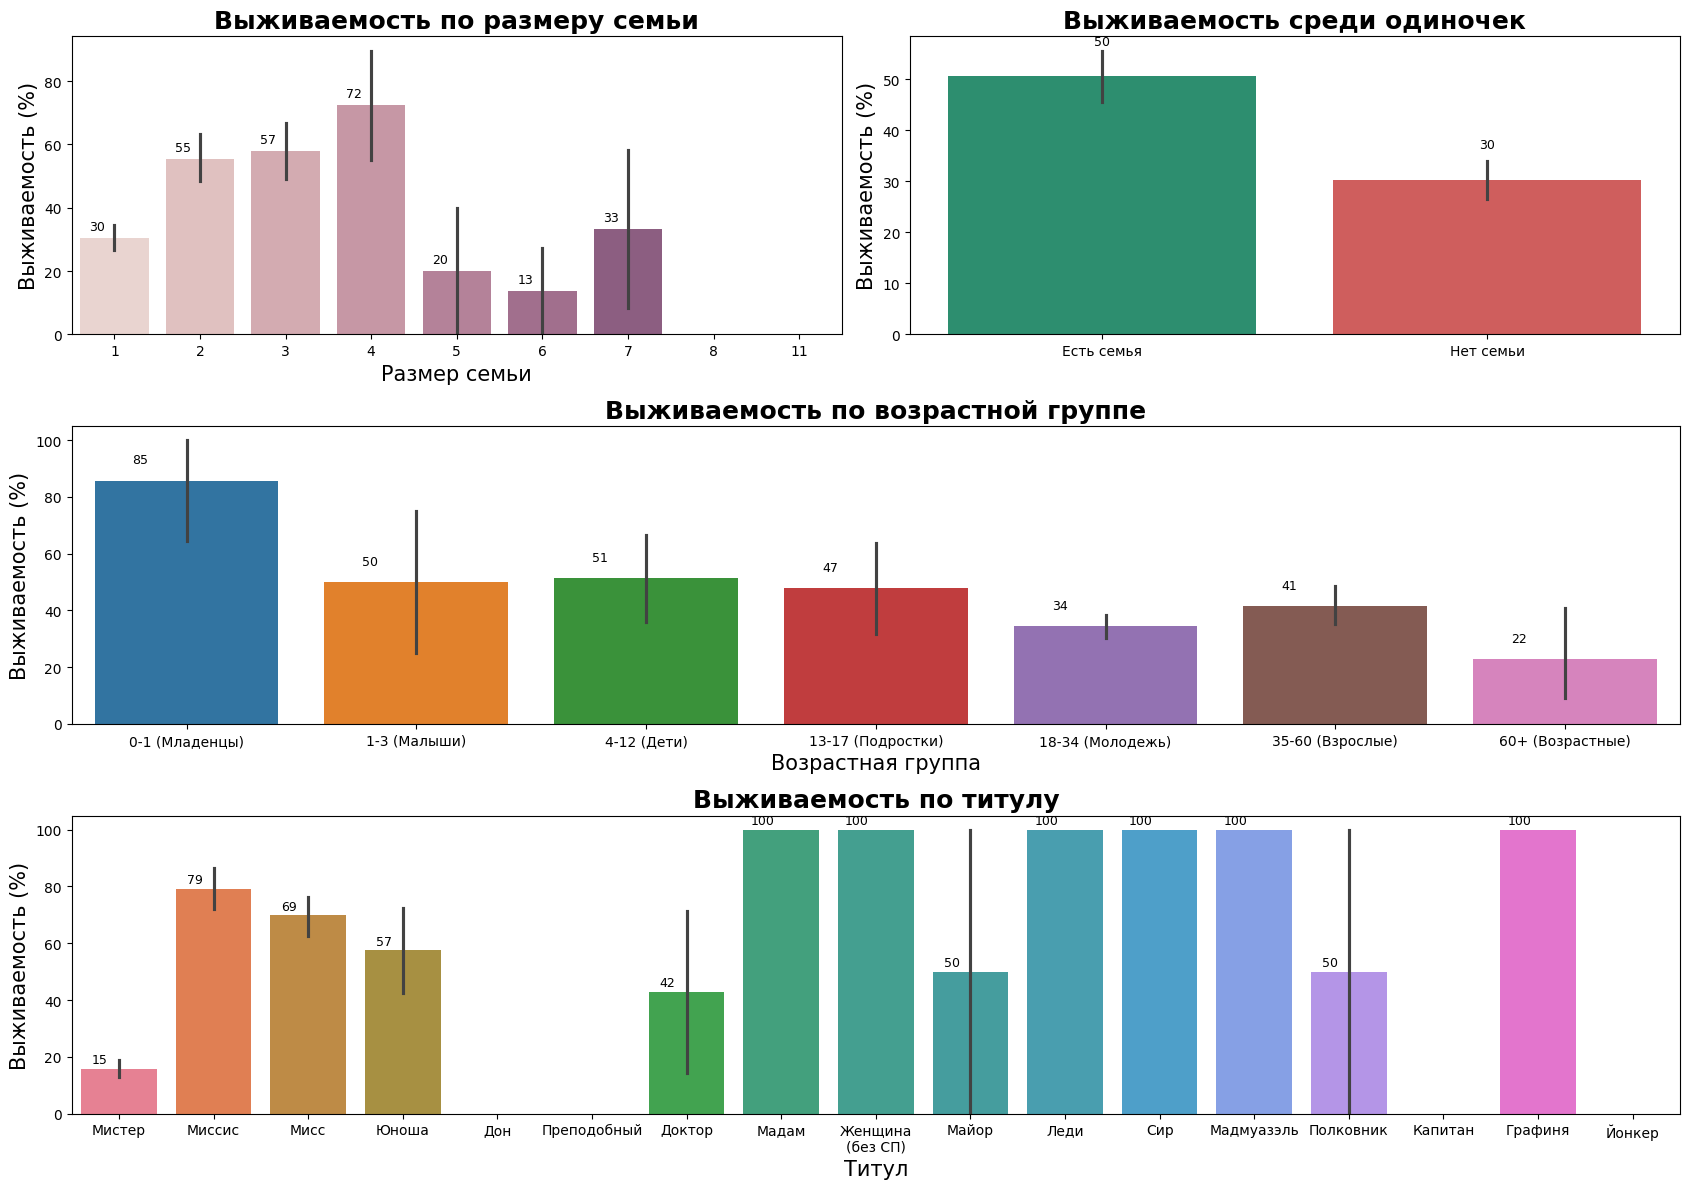

In [48]:
# Настройка холста и сетки 
fig, axes = plt.subplot_mosaic(
    [
        ["FamilySize", "IsAlone"],
        ["AgeGroup", "AgeGroup"],
        ["Title", "Title"]
    ],
    figsize=(17, 12)
)

# Столбчатая диаграмма распределения выживаемости по размеру семьи
sns.barplot(
    data=train_data,
    x="FamilySize",        
    y="Survived",
    estimator=lambda x: x.mean() * 100,
    hue="FamilySize",
    legend=False,
    ax=axes["FamilySize"]
)

# Настройка заголовка и подписей осей
axes["FamilySize"].set_title("Выживаемость по размеру семьи", 
             fontsize=18, fontweight="bold")
axes["FamilySize"].set_xlabel("Размер семьи", fontsize=15)
axes["FamilySize"].set_ylabel("Выживаемость (%)", fontsize=15)

# Подписи значений над столбиками
for p in axes["FamilySize"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["FamilySize"].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2 - 0.2, height + 2.5), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Столбчатая диаграмма распределения выживаемости среди одиноких людей
sns.barplot(
    data=train_data,
    x="IsAlone",        
    y="Survived",
    estimator=lambda x: x.mean() * 100,
    hue="IsAlone",
    palette=[GREEN, RED],
    legend=False,
    ax=axes["IsAlone"]
)

# Настройка заголовка, подписей осей и столбцов
axes["IsAlone"].set_title("Выживаемость среди одиночек", 
             fontsize=18, fontweight="bold")
axes["IsAlone"].set_xlabel("", fontsize=15)
axes["IsAlone"].set_ylabel("Выживаемость (%)", fontsize=15)
axes["IsAlone"].set_xticks([0, 1])
axes["IsAlone"].set_xticklabels(["Есть семья", "Нет семьи"])

# Подписи значений над столбиками
for p in axes["IsAlone"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["IsAlone"].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2, height + 6.1), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Столбчатая диаграмма распределения выживаемости по возрастной группе
sns.barplot(
    data=train_data,
    x="AgeGroup",
    y="Survived",
    estimator=lambda x: x.mean() * 100,
    hue="AgeGroup",
    legend=False,
    ax=axes["AgeGroup"]
)

# Настройка заголовка, подписей осей и столбцов
axes["AgeGroup"].set_title("Выживаемость по возрастной группе", 
             fontsize=18, fontweight="bold")
axes["AgeGroup"].set_xlabel("Возрастная группа", fontsize=15)
axes["AgeGroup"].set_ylabel("Выживаемость (%)", fontsize=15)
axes["AgeGroup"].set_xticks([0, 1, 2, 3, 4, 5, 6])
axes["AgeGroup"].set_xticklabels(["0-1 (Младенцы)", "1-3 (Малыши)", 
                                  "4-12 (Дети)", "13-17 (Подростки)", 
                                  "18-34 (Молодежь)", "35-60 (Взрослые)", 
                                  "60+ (Возрастные)"])

# Подписи значений над столбиками
for p in axes["AgeGroup"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["AgeGroup"].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2 - 0.2, height + 6.1), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )


# Столбчатая диаграмма распределения выживаемости по титулу
sns.barplot(
    data=train_data,
    x="Title",        
    y="Survived",
    estimator=lambda x: x.mean() * 100,
    hue="Title",
    legend=False,
    ax=axes["Title"]
)

# Настройка заголовка, подписей осей и столбцов
axes["Title"].set_title("Выживаемость по титулу", 
             fontsize=18, fontweight="bold")
axes["Title"].set_xlabel("Титул", fontsize=15)
axes["Title"].set_ylabel("Выживаемость (%)", fontsize=15)
axes["Title"].set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16])
axes["Title"].set_xticklabels(["Мистер", "Миссис", "Мисс", "Юноша", "Дон", "Преподобный", 
                               "Доктор", "Мадам", "Женщина\n(без СП)", "Майор", "Леди",
                               "Сир", "Мадмуазэль", "Полковник", "Капитан", "Графиня", 
                               "Йонкер"])

# Подписи значений над столбиками
for p in axes["Title"].patches:
    height = p.get_height() # высота столбца
    if height: # высота столбца != 0
        axes["Title"].annotate(
            str(int(height)), # приводим float к int, затем int приводим к str
            (p.get_x() + p.get_width() / 2 - 0.2, height + 2), # вычисляем координаты x и y подписи у столбика
            ha="center", fontsize=9 # по какому принципу привязываем надпись к координате, размер ее шрифта
        )

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиками в формате .svg
fig.savefig("plot20-23.svg")

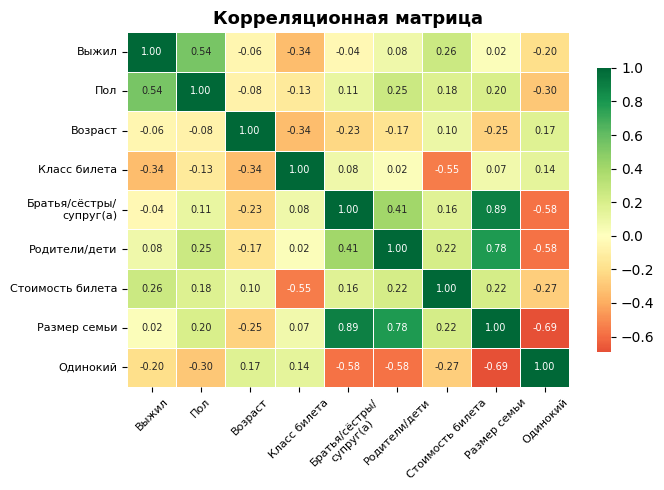

In [65]:
train_data["Sex_code"] = train_data["Sex"].map({"male": 0, "female": 1})

# Настройка холста и сетки 
fig, ax = plt.subplots(figsize=(7, 5))

# Настройка колонок и подписей к ним
corr_cols = ["Survived", "Sex_code", "Age", "Pclass","SibSp", "Parch", "Fare", "FamilySize",
            "IsAlone"]
corr_labels = {
    "Survived": "Выжил", "Sex_code": "Пол", "Age": "Возраст", "Pclass": "Класс билета", "SibSp": "Братья/сёстры/\nсупруг(а)",
    "Parch": "Родители/дети", "Fare": "Стоимость билета", 
    "FamilySize": "Размер семьи", "IsAlone": "Одинокий"
}

# Настройка корреляционной матрицы
corr_matrix = train_data[corr_cols].corr().round(2)
corr_matrix.index = [corr_labels[c] for c in corr_matrix.index]
corr_matrix.columns = [corr_labels[c] for c in corr_matrix.columns]

# Тепловая карта корреляций столбцов
sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8},
)

# Настройка заголовка и подписей осей
ax.set_title("Корреляционная матрица", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)

# Автоматический подбор отступов
plt.tight_layout()

# Экспорт файла с графиками в формате .svg
fig.savefig("plot24.svg")